# Tutorial 5: RJMCMC with Eryn

In the fifth tutorial, we will look at running Eryn when the underlying model is changing. This means we will be using Reversible-Jump MCMC, also referred to as trans-dimensional MCMC. In this tutorial, there will only be 2 tasks because RJMCMC is complicated and putting together an RJMCMC run takes time and effort. 

Reversible-Jump MCMC (RJMCMC)，跨维度 MCMC

In [48]:
# # if running in google colab
# !pip install eryn lisaanalysistools chainconsumer

In [49]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from lisatools.utils.constants import *
from copy import deepcopy  # can be useful

## Task 1: How many Gaussian pulses?

The first RJ problem we will look at is determining how many 2D Gaussian pulses exist in a noisy set of data. This is an example you can find in the more advanced Eryn tutorials. To keep this simple in the time we have alotted, we will use a proposal based on the prior distribution (this is the default). If you set `rj_moves=True` in the setup of `EnsembleSampler`, it will automatically generate RJ proposals from the prior. However, you must be careful when using multiple branches (model types) because this proposal, by default, always proposes to change each model in the sampler by 1 model count, either add or remove. 

Useful documentation:
* [EnsembleSampler](https://mikekatz04.github.io/Eryn/html/user/ensemble.html#eryn.ensemble.EnsembleSampler)
* [State](https://mikekatz04.github.io/Eryn/html/user/state.html#eryn.state.State)
* [uniform_dist](https://mikekatz04.github.io/Eryn/html/user/prior.html#eryn.prior.uniform_dist)
* [ProbDistContainer](https://mikekatz04.github.io/Eryn/html/user/prior.html#eryn.prior.ProbDistContainer)
* [GaussianMove](https://mikekatz04.github.io/Eryn/html/user/moves.html#eryn.moves.GaussianMove)
* [DistributionGenerateRJ](https://mikekatz04.github.io/Eryn/html/user/moves.html#eryn.moves.DistributionGenerateRJ)

基于先验分布意味着：程序会直接在先验范围（比如地图内）随机扔一个新脉冲。

In [50]:
from eryn.ensemble import EnsembleSampler
from eryn.state import State
from eryn.prior import ProbDistContainer, uniform_dist
from eryn.moves import GaussianMove
from eryn.backends import HDFBackend
from chainconsumer import ChainConsumer, Chain

We will do the initial setup for you. Here we are going to set the x and y dimensions of our 2D grid.

In [51]:
num     = 100 # the number of step for each dimension
lowlim  = -10 # Low limit on each axis
highlim = 10  # high limit on each axis
npulses = 10  # The # of injected pulses

dx = (highlim - lowlim) / num # Get the discritization

x, y = np.mgrid[lowlim:highlim:dx, lowlim:highlim:dx]  # Generate the grid

In [52]:
print(x)
print(x.shape)
print(np.array([[1,2],[3,4],[5,6]]).shape)
print(np.array([1,2]).shape)

[[-10.  -10.  -10.  ... -10.  -10.  -10. ]
 [ -9.8  -9.8  -9.8 ...  -9.8  -9.8  -9.8]
 [ -9.6  -9.6  -9.6 ...  -9.6  -9.6  -9.6]
 ...
 [  9.4   9.4   9.4 ...   9.4   9.4   9.4]
 [  9.6   9.6   9.6 ...   9.6   9.6   9.6]
 [  9.8   9.8   9.8 ...   9.8   9.8   9.8]]
(100, 100)
(3, 2)
(2,)


Now, we will draw initial parameters for each set of pules. Each pulse gets an amplitude, x, and y value.

In [53]:
Amp    = np.random.uniform(.5, 2.0, size=(npulses,)) # Draw an amplitude
# size需要给一个元组，.5=0.5,1D的size=10/size=(10,)是相同的，但是2D必须是元组
spread = .2  # Keep their spread as fixed for simplicity.
sigma  = spread * np.diag(np.ones(2))

edges = 2 # Utility parameter, in order to avoid having signals at the border of our data set

# Draw the coordinates parameters
# generates random x and y coordinates
inj_coordinates = np.random.uniform(lowlim+edges, highlim-edges, size=(npulses, 2))

# Gather all parameters here
gauss_inj_params = np.concatenate([Amp[:, None], inj_coordinates], axis=1)
# None是增加一个维度，（10，3）的数组

print(' * Parameters injected: \n\n', np.matrix(gauss_inj_params))

 * Parameters injected: 

 [[ 1.96359334 -4.17424537 -7.68233904]
 [ 1.68320531  6.11130555  5.10125703]
 [ 1.63875956 -5.57906597 -6.72291283]
 [ 0.83810745 -7.20736966  0.06914387]
 [ 1.29109195  3.0988943  -1.58332284]
 [ 0.70092851 -7.9364374  -1.62956862]
 [ 0.98753223  2.477439    6.70320029]
 [ 1.83644301 -1.2905263   5.22277598]
 [ 1.27811225 -2.5376788   3.18321099]
 [ 0.54425126  0.37338292  2.19720577]]


We have also filled in the Gaussian function and Likelihood to avoid any issues. The next few cells give an idea of the injection data. 

In [54]:
# First we compute some constant terms of the Gaussian models 
# (reminder: we have assumed a fixed spread for each pulse)
sigma_det = np.linalg.det(sigma)# 协方差行列式
sigma_inv = np.linalg.inv(sigma)# 协方差的逆
norm      = np.sqrt((2*np.pi)**2 * sigma_det)#归一化系数

def gaussian(X, Y, a, b, c):
    x = X[:,0]
    y = Y[0,:]
    # breakpoint()
    A = np.exp(-((x[None, :] - b[:, None]) ** 2) / (2 * sigma[0,0]))
    # x方向的轮廓
    B = np.exp(-((y[None, :] - c[:, None]) ** 2) / (2 * sigma[1,1]))
    # y方向的轮廓
    # breakpoint()
    C =  A[:, None, :] * B[:, :, None]
    #合成
     # (np.expand_dims(A,axis=0) * np.expand_dims(np.transpose(B),axis=2))

    return a[:, None, None] * C / norm

def log_prob_fn(x1, X, Y, data, sig):

    a = x1[:, 0]
    b = x1[:, 1]
    c = x1[:, 2]
    n = num * num

    template  = np.sum(gaussian(X, Y, a, b, c), axis=0)

    llh = - 0.5 * ( np.sum(((template - data)) ** 2) )
    llh *= 1/sig**2
    llh += - n*np.log(sig) - .5 * n * np.log(2.*np.pi)
    #归一化
    return llh

In [55]:
noise = spread * np.random.randn( num, num ) # Draw the random points for the noise
# Generate the data-set
injection = np.zeros( (num, num) )
injection = np.sum(gaussian(x, y, gauss_inj_params[:, 0], gauss_inj_params[:, 1], gauss_inj_params[:, 2]), axis=0)
data = injection + noise


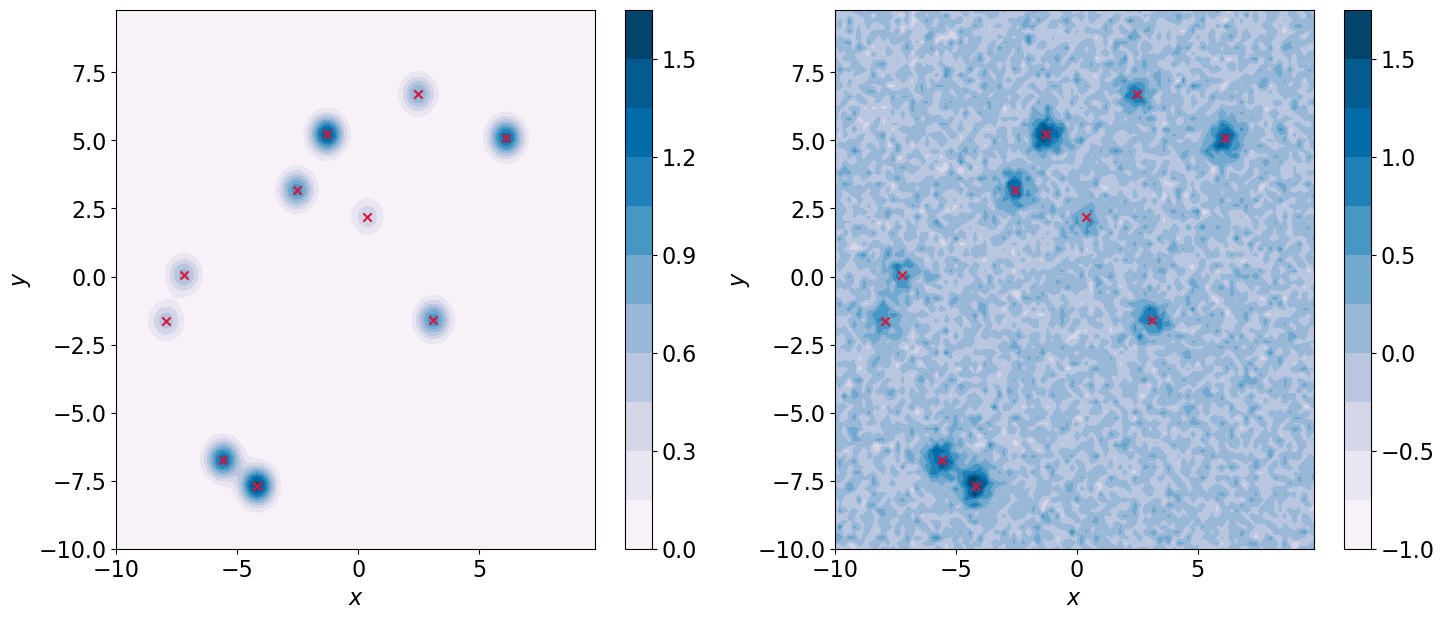

In [56]:
from matplotlib import cm

plt.figure(figsize=(17,7))
plt.subplot(121)
cf = plt.contourf(y, x, injection, 10, cmap=cm.PuBu)
plt.scatter(gauss_inj_params[:,1], gauss_inj_params[:,2], marker='x', color='#DC143C')
plt.colorbar(cf)
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')
plt.subplot(122)
cf = plt.contourf(y, x, data, 10, cmap=cm.PuBu)
plt.scatter(gauss_inj_params[:,1], gauss_inj_params[:,2], marker='x', color='#DC143C')
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')
plt.colorbar(cf)
plt.show()


Now that we have most of the initial setup. We now need to build our sampling run. Let's start by choosing settings and building base requirements: `ndims`, `nleaves_max`, `nleaves_min`, `branch_names`, `ntemps`, `nwalkers`.

In [57]:
ntemps = 10
nwalkers = 30
ndims        = {"pulse": 3} # 一个叶子（基本单元）XY和振幅
nleaves_max  = {"pulse": 2*npulses} #（最大数量，20个）
branch_names = ["pulse"]


Now we will setup our prior function. Make sure you initialize your prior with the `ProbDistContainer` object from Eryn. 
* For the amplitude, a uniform prior from 0.5 to 2.0.
* For x and y, uniform priors across the acceptable ranges.

In [58]:
priors = {
    "pulse": ProbDistContainer({
        0: uniform_dist(0.5, 2.),
        1: uniform_dist(lowlim, highlim),
        2: uniform_dist(lowlim, highlim),
    })
}

When using RJMCMC, we must input a value for `moves` in the `EnsembleSampler`. This is because the default proposal (Stretch proposal) does not work in varying dimensionality. We will keep this simple and use a Gaussian proposal centered on the current point. We recommend a diagonal covariance matrix with the same covariance for each parameter. There are many ways to do this. 

Useful Documentation:
* [GaussianMove](https://mikekatz04.github.io/Eryn/html/user/moves.html#eryn.moves.GaussianMove)

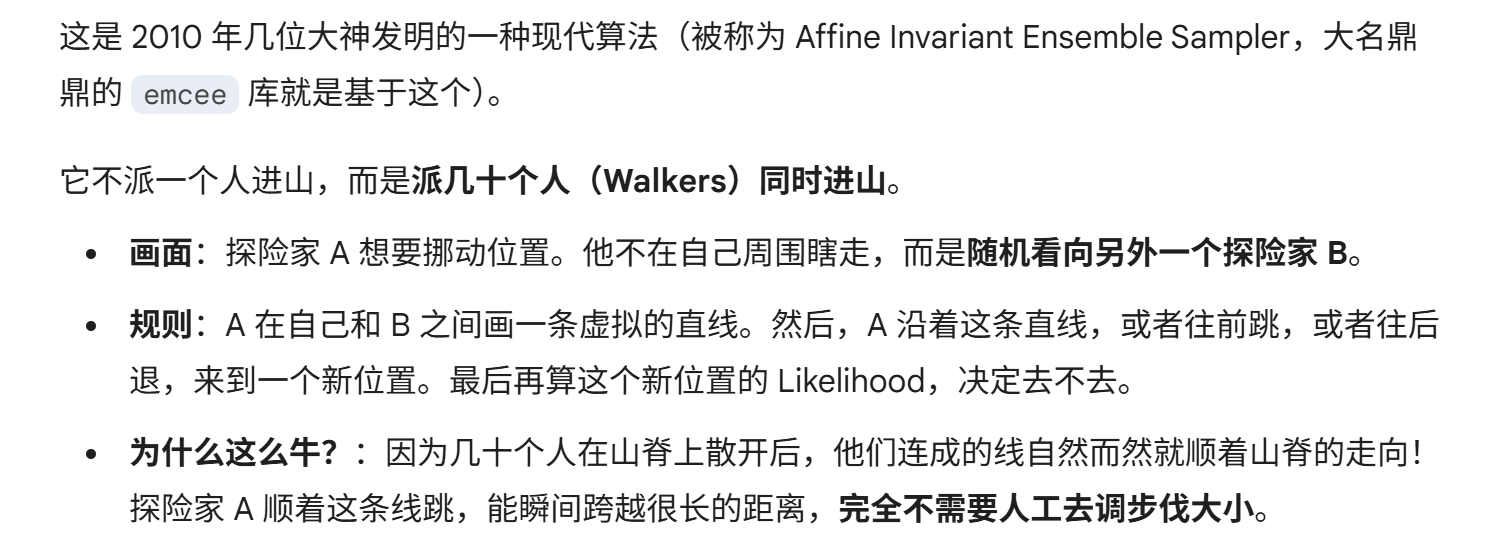
这与最开始的Metropolis-Hastings (MH) 算法不同

但是RJMCMC会让Stretch Move失效，因为每个walker可能认为他们地图中的维数不同，有的认为是5个源，有的认为是6个

In [59]:
# imports 
from eryn.moves import GaussianMove

对角协方差矩阵：“在 X 坐标、Y 坐标和振幅这三个方向上，迈的步子差不多大就行了，彼此互不干扰，怎么简单怎么来。”

In [60]:
factor = 0.01
cov    = {"pulse": np.diag(np.ones(3)) * factor}
moves = GaussianMove(cov)

Now we will instantiate the `EnsembleSampler`. For the tempering, set `tempering_kwargs=dict(ntemps=ntemps)`. 

In [61]:
ensemble = EnsembleSampler(
    nwalkers,
    ndims,#每个叶子的维数
    log_prob_fn,
    priors,
    args=[x, y, data, sigma_det],
    tempering_kwargs=dict(ntemps=ntemps),
    nbranches=len(branch_names),
    branch_names=branch_names,
    nleaves_max=nleaves_max,
    #nleaves_min=nleaves_min,
    moves=moves,
    rj_moves=True,
)

With the sampler prepared, we just need to generate our starting points. There are also many choices for this. In RJMCMC, it is more complicated because of the model uncertainty. For this simplified example, we are going to start by drawing **1 Gaussian per walker** from the prior. It will add more as the goes. Your goal here is to produce a `coords` dictionary of shape `(ntemps, nwalkers, nleaves_max, ndim)`. You can sample every source in that `coords` array because we will direct to have **only one** leaf per walker with the `inds` dictionary. `inds` should be a boolean array of shape `(ntemps, nwalkers, nleaves_max)`. You then index this and set one value to True per walker. Fill these dictionaries into a `State` object.

Eryn 底层写死的物理规则。在 Eryn 计算 Likelihood（打分）的时候，它有一行极其核心的代码，逻辑大概是这样的：
有效参数 = coords * inds
任何坐标，只要它对应的 inds 是 False，在底层计算时就会直接被“屏蔽”或者“乘零抹除”。Eryn 就是靠这张 True/False 的清单，来决定算几个人头的分数的。

In [62]:
coords = {
    'pulse': priors['pulse'].rvs(size=(ntemps, nwalkers, nleaves_max["pulse"]))
} 
"""coords = {
    name: priors[name].rvs(size=(ntemps, nwalkers, nleaves_max[name]))
    for name in branch_names 这是更万能的模板
}"""
# 10个温度，30个探险家，都有20个leaf
inds_tmp = np.zeros(coords['pulse'].shape[:-1], dtype=bool)
#初始化都是False（zero->0->False）
#除了第一个leaf，也就是第一个源，其他都先不上场（False）
inds_tmp[:, :, 0] = True

inds = {'pulse': inds_tmp}
state = State(coords, inds=inds)

Now run the sampler. We recommend a good burn in.

In [63]:
np.in1d = np.isin

thin_by=10 的意思就是“抽帧”：探险家在山里走，每走 10 步，你才按一次快门拍张照存下来。这样既省硬盘，存下来的脚印又足够分散、有代表性。

In [64]:
nsteps = 5000
output = ensemble.run_mcmc(state, nsteps, burn=1000, progress=True)

  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 5000/5000 [07:18<00:00, 11.40it/s]


Now read out the number of leaves per walker in the cold chain using the `ensemble.backend`. You only need the `inds` array for this. Plot a histogram of number of pulses found in the cold chain. This is a posterior distribution on the model count. 

Useful Documentation:
* [Backend](https://mikekatz04.github.io/Eryn/html/user/backend.html#eryn.backends.Backend)

In [65]:
print(ensemble.backend.get_nleaves()["pulse"].shape)

(5000, 10, 30)


<>:21: SyntaxWarning: invalid escape sequence '\#'
<>:21: SyntaxWarning: invalid escape sequence '\#'
/tmp/ipykernel_1421/1910620305.py:21: SyntaxWarning: invalid escape sequence '\#'
  plt.xlabel("$\#$ of peaks in the data")


Text(0.5, 0, '$\\#$ of peaks in the data')

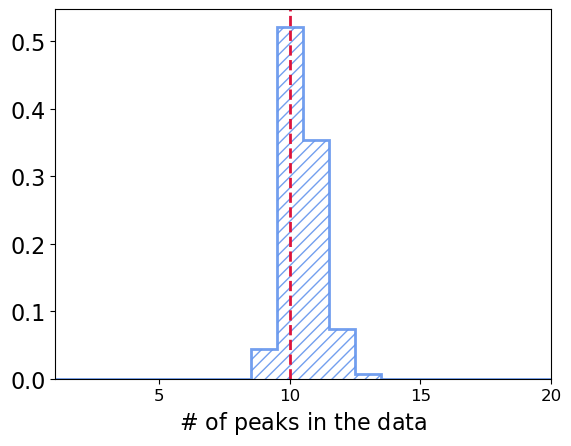

In [66]:
nleaves = ensemble.backend.get_nleaves()["pulse"][:, 0].flatten() 
#[:,0]=[:,0,:]
bins = (np.arange(1, nleaves_max['pulse'] + 2) - 0.5)  # Get maximum allowed number of leaves for the given branch

plt.hist(
    nleaves,
    bins=bins,
    color='#6495ed',
    alpha=0.9,
    lw=2,
    histtype='step',
    density=True,
    hatch='///'
)

# injection line 

plt.axvline(x=int(npulses), linestyle='--', lw=2, color='#DC143C')
plt.xticks(fontsize=12)
plt.xlim(1, 20)
plt.xlabel("$\#$ of peaks in the data")


### Question:
Is this what you expected? Does RJMCMC tell us what the "right" answer is? How do you think the noise effects this posterior plot? If we increase the noise, what type of changes do we expect and why?

Now we will look at the parameters of the recovered pulses to see how well we located the injected pulses. To do this, we are going to flatten all of samples from all leaf counts found, i.e. we will take every single source in the cold chain and plot all of these overlayed. **Hint**: use the `inds` array to your advantage here.

We recommend using `pandas` and `chainconsumer` to do this, but you can do it anyway you like. 

In [67]:
import pandas as pd

Parameter $A$ in chain Test is not constrained
Parameter $x$ in chain Test is not constrained
Parameter $y$ in chain Test is not constrained


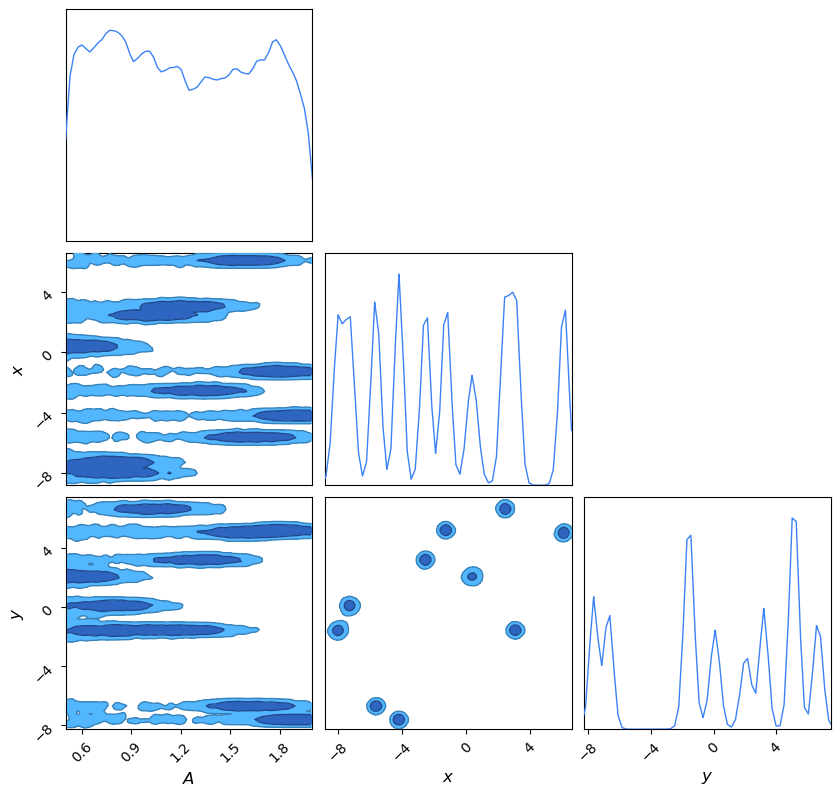

In [68]:
pulse_parameters = ["$A$", r"$x$", r"$y$"]

# 2. 提取“真正在场上”的有效样本数据
# get_chain 拿到所有数据，get_inds 作为布尔开关过滤掉 False（废弃）的替补席数据
samples_pulses = ensemble.backend.get_chain()['pulse'][ensemble.backend.get_inds()["pulse"]]

# 3. 矩阵转置与组装 Pandas 表格
# samples_pulses 原始形状为 (有效样本总数, 参数个数)
# .T 将其转置为 (参数个数, 有效样本总数)，以适配 zip 的按列打包逻辑
#zip(A, B) 的规矩是：从 A 里拿第 1 个元素，从 B 里拿第 1 个元素，凑成一对。
df = pd.DataFrame({key: val for key, val in zip(pulse_parameters, samples_pulses.T)})

# 4. 实例化画图大师并开启平滑滤镜
c = ChainConsumer()
check = int(1) # KDE 平滑级别

# 5. 将数据链装填进画图队列，并绘制
c.add_chain(Chain(samples=df, name="Test", smooth=check))
fig = c.plotter.plot()

### Question:
How did we do? Was it a success? Could there be improvements? 

## Task 2: Model selection with RJMCMC

In this task, you will use RJMCMC to do a direct model comparison. This will be the same model comparison used in Tutorial 3 comparing a Gaussian pulse with a Cauchy pulse. In tutorial 3, we used fixed-dimensional MCMC and thermodynamic integration to estimate the evidence of each model. Then we compared them to get the Bayes Factor. Using RJMCMC will produce a posterior distribution on the model selection index rather than a direct evidence for each model. The fraction of walkers that have highlighted one model over the other represents a proxy for the odds ratio. This is not strictly true when one model is much more favored than another. However, when model favorability is close, this direct computation is okay. 

For simplicity, we will consider the spread of the signal to be 1. Therefore, we are only fitting and comparing the amplitude and mean of the pulse. 

Once again, we will start by providing the functions for the Gaussian pulse, Cauchy pulse, and the Likelihood function. 

在两个模型相差较大的时候，这就不是十分严格了，因为可能另一个模型在RJMCMC中都不会被使用1次，这样就无从比较一个模型比另一个模型好多少。此时就需要用热力学积分的方法。

现在运用RJMCMC将两个模型，是两个分支（branch），RJMCMC允许在这两个模型中反复横跳，如果一个模型用的比较多，说明这个模型好。比值可以来量化好多少。

In [69]:
from scipy.stats import cauchy
def gaussian_pulse(x, a, b):
    f_x = a * np.exp(-((x - b) ** 2) / (2 * 1.0 ** 2))
    return f_x

def cauchy_pulse(x, a, b):
    f_x = a *np.pi *cauchy.pdf(x - b)
    return f_x

def log_like_fn(params, t, data, sigma, which_template):

    pulse_gen = gaussian_pulse if which_template == "gauss" else cauchy_pulse
    template = pulse_gen(t, *params)

    ll = -0.5 * np.sum(((template - data) / sigma) ** 2, axis=-1)
    return ll

def log_like_wrap(params, *args):
    # must be careful about how these models are read into the Likelihood function
    # In this case, we will have one model with a single set of parameters 
    # and one model that is None
    
    assert len(params) == 2
    if params[0] is not None:
        assert params[1] is None
        # gauss will be first set of params
        args += ("gauss",)
        ll = log_like_fn(params[0][0], *args)
# 第一个[0]是branch的编号，第二个[0]是leaf的编号
    else:
        assert params[0] is None
        # gauss will be first set of params
        args += ("cauchy",)
        ll = log_like_fn(params[1][0], *args)

    return ll

args += ("gauss",)：这是一种动态传递参数的技巧。它把字符串“gauss”塞进 args 里，传给 log_like_fn。

We will inject the Gausian pulse and compare to the Cauchy pulse.

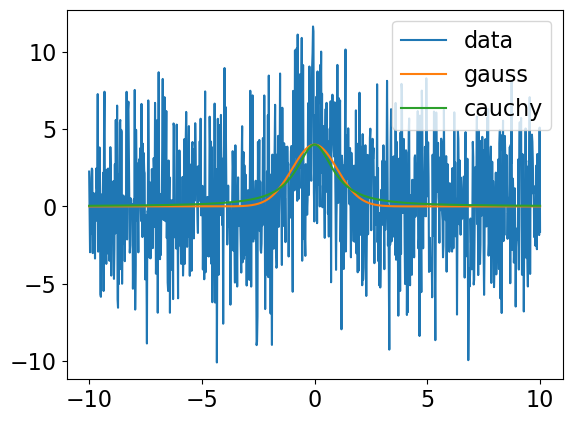

In [71]:
t_vals = np.linspace(-10.0, 10.0, 1000)
sigma = 3.5
amp_true = 4.0
mean_true = 0.0
true_data = gaussian_pulse(t_vals, amp_true, mean_true)
data = true_data + np.random.randn(*t_vals.shape) * sigma
#加上噪声
cauchy_data = cauchy_pulse(t_vals, amp_true * np.pi, mean_true)
plt.plot(t_vals, data, label="data")
plt.plot(t_vals, true_data, label="gauss")
plt.plot(t_vals, cauchy_data, label="cauchy")
plt.legend()
# plt.plot(x_vals, np.exp(log_like_fn()))
# plt.plot(x_vals, np.exp(log_like_gauss(x_vals)))

We will follow the same setup order as the last problem. Start with the basic declarations (`ntemps`, `ndims`, etc.). For this problem, the max leaves for both models should be 1 and the min leaves for both models should be 0. 

In [74]:
ntemps = 10
nwalkers = 30

ndims        = {"gauss": 2, "cauchy": 2} 
nleaves_max  = {"gauss": 1, "cauchy": 1}  
nleaves_min = {"gauss": 0, "cauchy": 0}
branch_names = ["gauss", "cauchy"]

Now we will put together the priors for both models. The priors are identical really for the two models. The amplitude prior should span the injection values. The mean prior should span the domain of time.

In [75]:
priors = {}#priors是一个字典，key是分支的名字，value是一个ProbDistContainer对象，里面包含了每个参数的先验分布
priors["gauss"] = ProbDistContainer({
    0: uniform_dist(0.0, 40.0),#振幅的先验
    1: uniform_dist(t_vals.min(), t_vals.max())#均值的先验
}) 

priors["cauchy"] = ProbDistContainer({
    0: uniform_dist(0.0, 40.0),
    1: uniform_dist(t_vals.min(), t_vals.max())
}) 


Now we will produce the same type of `GaussianMove` that we built earlier. We need to make sure that to provide a covariance for each model! So, it must be a dictionary with entries for both models. The entries can really be the same though. 

In [72]:
# 这都是很流程化的，和上文一样，设置GaussianMove
factor = 0.01
cov    = {"gauss": np.diag(np.ones(2)) * factor, "cauchy": np.diag(np.ones(2)) * factor}
moves = GaussianMove(cov)

A Metropolis step with a Gaussian proposal function.

    This class is heavily based on the same class in ``emcee``.

    Args:
        cov (dict): The covariance of the proposal function. The keys are branch names and the
            values are covariance information. This information can be provided as a scalar,
            vector, or matrix and the proposal will be assumed isotropic,
            axis-aligned, or general, respectively.

Instantiate the `EnsembleSampler`.

In [77]:
sampler = EnsembleSampler(
    nwalkers,
    ndims,
    log_like_wrap,
    priors,
    nbranches=2,
    branch_names=branch_names, 
    tempering_kwargs=dict(ntemps=ntemps, Tmax=np.inf),
    args=(t_vals, data, sigma),
    rj_moves=True,
    moves=moves,
    nleaves_max=nleaves_max,
    nleaves_min=nleaves_min
)

Generate start points. **Note**: this is very important. This test will only work if:
* we have **2** models,
* each model has max leaves of 1 and min leaves of 0,
* and the starting points must all have **either** the Gaussian or Cauchy pulse, not both and not neither.

In this setup, each proposal will propose to switch the model and draw from its prior. 

Generate your start point and use the `inds` array to tell the sampler that each walker has only one model instance. 

开局，每一个walker只能选择一个模型，否则无法实现后面的换模型，也就是无法换实现“跳槽”。

In [86]:
start_point = {name: priors[name].rvs(size=(ntemps, nwalkers, 1)) for name in branch_names}

model_index = np.random.randint(0, 2, size=(ntemps, nwalkers, 1))
#随机分配index，0代表gauss，1代表cauchy，可以随机初始值
inds = {name: np.zeros((ntemps, nwalkers, 1), dtype=bool) for name in branch_names}
#初始化，inds都为False
inds["gauss"][model_index == 0] = True
inds["cauchy"][model_index == 1] = True

assert np.all(inds["gauss"].astype(int) + inds["cauchy"].astype(int) == 1)
# 验证第三条件：每个探险家只能在一个分支上
# astype(int)是把bool转成int，True->1，False->0，所以加起来应该等于1
start_state = State(start_point, inds=inds)



In [95]:
#print(inds["gauss"].astype(int))
print(inds["cauchy"].shape)
A=inds["gauss"].astype(int) + inds["cauchy"].astype(int)
print(A.shape)

(10, 30, 1)
(10, 30, 1)


Run the sampler with a burn-in.

In [96]:
nteps = 500
sampler.run_mcmc(start_state, nsteps, progress=True, burn=100)

100%|██████████| 5000/5000 [01:58<00:00, 42.04it/s]


To find our posterior odds ratio, we need to get the fraction of cold-chain samples that exist in one of the two states. Calculate the odds ratio.

In [97]:
nleaves = sampler.get_nleaves()

In [101]:
print(nleaves["gauss"].shape)
print(nleaves)

(5000, 10, 30)
{'gauss': array([[[1, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 1, 1, 0],
        [0, 1, 1, ..., 1, 1, 0],
        ...,
        [0, 1, 1, ..., 1, 0, 1],
        [1, 1, 0, ..., 1, 1, 1],
        [0, 1, 0, ..., 0, 0, 1]],

       [[1, 1, 1, ..., 0, 0, 0],
        [1, 0, 1, ..., 1, 1, 0],
        [0, 0, 0, ..., 0, 1, 0],
        ...,
        [0, 1, 1, ..., 0, 1, 0],
        [1, 0, 0, ..., 1, 1, 0],
        [0, 1, 0, ..., 1, 1, 0]],

       [[1, 0, 0, ..., 0, 0, 1],
        [1, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 1, 0],
        ...,
        [1, 0, 0, ..., 0, 1, 1],
        [0, 0, 1, ..., 0, 1, 1],
        [0, 0, 0, ..., 1, 0, 1]],

       ...,

       [[1, 1, 0, ..., 0, 1, 1],
        [0, 0, 1, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 1, ..., 1, 1, 0],
        [0, 0, 1, ..., 0, 1, 0],
        [0, 1, 0, ..., 1, 1, 0]],

       [[1, 1, 1, ..., 0, 1, 1],
        [1, 0, 1, ..., 1, 0, 0],
        [1, 0, 0, ..., 0, 1, 0],
        ...

In [108]:
A=nleaves["gauss"][:, 0,:].sum() / np.prod(nleaves["gauss"][:, 0,:].shape)
# 第一个是gauss/总样本数
#prod是求积，shape是（5000,30），所以prod是5000*30=150000
B=nleaves["gauss"][:, 0,:].sum() / nleaves["cauchy"][:, 0,:].sum()
#第二个是gauss/cauchy
print(A,B)

0.6442266666666666 1.8107783982310834


In [111]:
nleaves["gauss"][:, 0,:].shape

(5000, 30)

和答案的0.437不同的是，这可能是由于两个模型的差异并不大，且噪声的随机性。

### Question:
If we change the noise, what effect will this have on our results? What happens when one model is heavily favored so that the fraction is 1? Is this a proper estimate of the odds ratio? What could we do in this case where the initial odds ratio is 1 to actually estimate the odds ratio?

噪声变大，会让两个模型看起来更像。如果改小，可能这个比值就会趋向于1，gauss的会更好一点。

如果ratio=1，则说明高斯的模型拟合的太好，无法跳到Cauchy,跳到Cauchy的概率非常低

这样模型相比就不是ratio了，这只是一个下限，如果数量变得足够大，步数足够多，会越来越接近这个真实得结果。

当ratio=1得时候，就要求助于热力学积分。